In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Input
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [2]:
# Dataset con palabras ambiguas
# 0 = sentido fisico / concreto / literal
# 1 = sentido alternativo / institucional / abstracto

frases=[]
etiquetas=[]

# BANCO
# 0 = asiento / banca
# 1 = institucion financiera

banco_fisico = [
    "me sente en el banco de la plaza",
    "el banco del parque estaba mojado",
    "pintaron el banco de madera de color azul",
    "el niño salto sobre el banco del jardin",
    "arreglaron el banco frente a la fuente",
    "el banco viejo estaba roto por la lluvia",
    "dejaron la mochila encima del banco del parque",
    "el banco de la escuela era muy incomodo",
    "la banca de concreto estaba fria en la mañana",
    "encontramos un banco vacio junto al arbol",
    "el abuelo descansa en el banco de piedra",
    "movieron el banco de hierro hacia la sombra",
    "el banco del muelle tiene vista al mar",
    "construyeron un banco rustico con troncos",
    "el carpintero barnizo el banco ayer",
    "nos sentamos en el banco a comer un helado",
    "el banco de la parada del autobus esta sucio",
    "las palomas se posaron en el banco vacio",
    "rompieron el respaldo del banco publico",
    "limpiaron el banco antes de sentarse"
]

banco_financiero = [
    "el banco aprobo el credito del cliente",
    "el banco central anuncio nuevas tasas",
    "la sucursal del banco abrio muy temprano",
    "el banco rechazo la solicitud del prestamo",
    "los clientes entraron al banco principal",
    "el banco reporto ganancias este trimestre",
    "la directora del banco dio una conferencia",
    "el banco aumento la tasa de interes",
    "la cuenta del banco fue bloqueada",
    "el banco ofrecio un nuevo producto financiero",
    "fui al banco a depositar mi quincena",
    "el cajero del banco me dio billetes falsos",
    "la aplicacion del banco esta fallando hoy",
    "el banco internacional abrio una sede aqui",
    "me llamaron del banco para ofrecer una tarjeta",
    "el banco me cobra comisiones muy altas",
    "transferi los fondos a otro banco",
    "el gerente del banco firmo los documentos",
    "el banco hipotecario financio mi casa",
    "hay mucha gente esperando afuera del banco"
]

# CURA
# 0 = tratamiento médico
# 1 = sacerdote

cura_tratamiento = [
    "la cura fue efectiva para el paciente",
    "los medicos probaron una nueva cura",
    "la cura redujo los sintomas rapidamente",
    "esperan encontrar una cura definitiva",
    "la cura experimental funciono en el hospital",
    "la cura tardo semanas en hacer efecto",
    "la investigacion busca una cura estable",
    "la cura medica fue aprobada este año",
    "la cura alivio el dolor del enfermo",
    "los cientificos desarrollan una cura innovadora",
    "la cura para el virus aun esta en desarrollo",
    "aplicaron la cura mediante una inyeccion",
    "el laboratorio patento la nueva cura",
    "la cura milagrosa resulto ser un fraude",
    "el paciente reacciono bien a la cura",
    "descubrieron la cura despues de años de estudio",
    "la cura tropical se extrae de una planta",
    "no existe una cura conocida para este mal",
    "la cura alternativa mejoro su salud",
    "el tratamiento es una cura a largo plazo"
]

cura_sacerdote = [
    "el cura pronuncio un discurso en la iglesia",
    "el cura saludo a los asistentes de la misa",
    "el cura hablo con la comunidad del pueblo",
    "el cura organizo una reunion parroquial",
    "el cura bendijo a los recien casados",
    "el cura visito a varias familias del barrio",
    "el cura encendio las velas del altar",
    "el cura escucho las confesiones del domingo",
    "el cura acompaño la procesion de la tarde",
    "el cura explico el mensaje del evangelio",
    "el cura de la catedral es muy estricto",
    "el cura ofició el bautizo esta mañana",
    "el cura pidio donaciones para los huerfanos",
    "el cura rezo el rosario con los fieles",
    "el cura del monasterio vive en silencio",
    "el cura llevo la comunion a los enfermos",
    "el cura vistio su tunica blanca",
    "el cura joven llego a la parroquia hoy",
    "el cura toco las campanas al mediodia",
    "el cura leyo un pasaje de la biblia"
]

# CAPITAL
# 0 = dinero / recurso financiero
# 1 = ciudad principal

capital_dinero = [
    "la empresa aumento su capital este año",
    "el inversionista perdio gran parte del capital",
    "necesitan mas capital para crecer",
    "el capital inicial fue insuficiente",
    "la firma extranjera inyecto capital nuevo",
    "el capital privado financio el proyecto",
    "la startup consiguio capital de riesgo",
    "el capital acumulado mejoro la operacion",
    "el negocio requiere capital adicional",
    "el capital disponible se redujo por la crisis",
    "el capital humano es lo mas importante de la empresa",
    "sin capital no podemos abrir el restaurante",
    "los socios aportaron el capital necesario",
    "el flujo de capital fue constante",
    "el banco congelo el capital de la corporacion",
    "el capital invertido genero grandes rendimientos",
    "fugaron su capital a cuentas en el extranjero",
    "el capital social de la compañia aumento",
    "compraron maquinaria con su propio capital",
    "el exceso de capital provoco inflacion"
]

capital_ciudad = [
    "la capital del pais recibe muchos turistas",
    "viajaron a la capital para una reunion",
    "la capital concentro el poder politico",
    "la capital amanecio con mucho trafico",
    "la capital fue fundada hace siglos",
    "los museos de la capital estaban llenos",
    "la capital se preparo para el desfile",
    "la capital tiene una gran poblacion",
    "el tren llego a la capital al amanecer",
    "la capital organiza eventos internacionales",
    "el presidente dio un discurso en la capital",
    "la capital de francia es muy hermosa",
    "los vuelos hacia la capital estan retrasados",
    "hubo protestas en el centro de la capital",
    "el alcalde de la capital inauguro un puente",
    "la capital financiera atrae muchos negocios",
    "el clima en la capital es muy frio",
    "la vida en la capital es muy acelerada",
    "el gobierno mudo sus oficinas a la capital",
    "la capital provincial celebra sus fiestas"
]

# RATON
# 0 = animal
# 1 = dispositivo de computadora

raton_animal = [
    "el raton corrio debajo de la mesa",
    "el gato persiguio al raton gris",
    "el raton salio de su escondite",
    "un raton pequeño aparecio en la cocina",
    "el raton se movio entre las cajas",
    "escucharon al raton durante la noche",
    "el raton royo una bolsa de pan",
    "el raton huyo cuando encendieron la luz",
    "vieron un raton cerca del almacen",
    "el raton se escondio tras el armario",
    "pusieron una trampa de queso para el raton",
    "el buho atrapo un raton en el bosque",
    "el raton de campo destruyo la cosecha",
    "el laboratorio usa un raton blanco para pruebas",
    "el raton es un roedor muy escurridizo",
    "hay un nido de raton en el atico",
    "el raton asusto a todos en el comedor",
    "el raton mordio los cables del motor",
    "el aguila detecto al raton desde el cielo",
    "el raton chillo cuando lo acorralaron"
]

raton_dispositivo = [
    "el raton dejo de funcionar en la oficina",
    "compre un raton inalambrico para la laptop",
    "el raton optico era muy preciso",
    "cambio la bateria del raton bluetooth",
    "el raton de la computadora estaba roto",
    "necesito un raton ergonomico para trabajar",
    "el raton respondia con retraso",
    "limpiaron el sensor del raton",
    "conecte el raton a un puerto usb",
    "el raton nuevo tenia varios botones",
    "hice clic derecho con el raton",
    "el cursor del raton desaparecio de la pantalla",
    "compre una alfombrilla para deslizar el raton",
    "la rueda del raton hace un ruido raro",
    "el raton gamer tiene luces de colores",
    "el raton se desconecto repentinamente",
    "arrastre la ventana usando el raton",
    "el raton tactil de la laptop es incomodo",
    "configure la velocidad de movimiento del raton",
    "el cable del raton se enredo en el teclado"
]

# COLA
# 0 = fila de personas
# 1 = parte del animal

cola_fila = [
    "la cola avanzaba lentamente en la entrada",
    "hicimos cola durante dos horas",
    "la cola del cine daba vuelta a la esquina",
    "la cola para pagar era enorme",
    "la cola del supermercado fue muy larga",
    "la cola comenzo antes del amanecer",
    "la cola de clientes llego hasta la calle",
    "la cola se movio mas rapido despues",
    "todos esperaron en cola con paciencia",
    "la cola del estadio bloqueo el paso",
    "me meti en la cola equivocada en el banco",
    "la cola del peaje causaba mucho trafico",
    "alguien se metio en la cola sin permiso",
    "la cola de la taquilla avanza por turnos",
    "esperamos al final de la cola",
    "la cola para subir al avion ya empezo",
    "hicimos cola bajo la lluvia intensa",
    "la cola del concierto estaba llena de jovenes",
    "no soporto estar en una cola tan lenta",
    "el guardia organizo la cola de personas"
]

cola_animal = [
    "el perro movia la cola sin parar",
    "la cola del gato estaba erizada",
    "el caballo golpeo la cola contra el aire",
    "la cola del zorro era muy espesa",
    "la cola del mono colgaba del arbol",
    "el veterinario reviso la cola del animal",
    "la cola del leon se movia despacio",
    "el pez perdio parte de la cola",
    "la cola de la ardilla era enorme",
    "la cola del perro estaba mojada",
    "el reptil mudo la piel de su cola",
    "el pavo real desplego su hermosa cola",
    "la lagartija perdio la cola al escapar",
    "el escorpion ataco con la punta de su cola",
    "el castor golpeo el agua con la cola",
    "la sirena tenia una brillante cola de pez",
    "la cola del cocodrilo es muy pesada",
    "el lobo escondio la cola entre las patas",
    "el pajaro tenia plumas rojas en la cola",
    "la cola del tigre es larga y rayada"
]

def agregar_ejemplos(lista_frases, etiqueta):
  for frase in lista_frases:
    frases.append(frase)
    etiquetas.append(etiqueta)

agregar_ejemplos(banco_fisico, 0)
agregar_ejemplos(banco_financiero, 1)

agregar_ejemplos(cura_tratamiento, 0)
agregar_ejemplos(cura_sacerdote, 1)

agregar_ejemplos(capital_dinero, 0)
agregar_ejemplos(capital_ciudad, 1)

agregar_ejemplos(raton_animal, 0)
agregar_ejemplos(raton_dispositivo, 1)

agregar_ejemplos(cola_fila, 0)
agregar_ejemplos(cola_animal, 1)

df= pd.DataFrame({
    "frase": frases,
    "etiqueta": etiquetas
})

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head(10))
print("\nTotal de ejemplos:", len(df))
print("\nBalance de clases:")
print(df["etiqueta"].value_counts())

                                              frase  etiqueta
0  el capital invertido genero grandes rendimientos         0
1        nos sentamos en el banco a comer un helado         0
2              fui al banco a depositar mi quincena         1
3    configure la velocidad de movimiento del raton         1
4                 vieron un raton cerca del almacen         0
5       la capital financiera atrae muchos negocios         1
6          el cura explico el mensaje del evangelio         1
7         me meti en la cola equivocada en el banco         0
8                     esperamos al final de la cola         0
9             la cura tardo semanas en hacer efecto         0

Total de ejemplos: 200

Balance de clases:
etiqueta
0    100
1    100
Name: count, dtype: int64


In [3]:
# Tokenizacion y padding

X=df["frase"].tolist()
y=df['etiqueta'].tolist()

X_train, X_test, y_train, y_test= train_test_split(
    X,y,test_size=0.2, stratify=y)

tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Convertimos a secuencias de numeros
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Obtenemos la llongitud mas larga de la secuencia de entrenamiento
max_len = max(len(seq) for seq in X_train_seq)

# Padding: Rellenar de 0 las frases mas cortas para igualarlas
# Post es para colocar los 0 al final
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

vocab_size = len(tokenizer.word_index)+1

print("Vocabulario:", vocab_size)
print("max_len:", max_len)
print("Dimensiones de X_train:", X_train_pad.shape)
print("Dimensiones de X_test:", X_test_pad.shape)

Vocabulario: 485
max_len: 10
Dimensiones de X_train: (160, 10)
Dimensiones de X_test: (40, 10)


In [4]:
# LSTM Simple

modelo_lstm_simple = Sequential()
modelo_lstm_simple.add(Input(shape=(max_len,)))

modelo_lstm_simple.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

modelo_lstm_simple.add(LSTM(32))

modelo_lstm_simple.add(Dense(1, activation="sigmoid"))

modelo_lstm_simple.compile(
    optimizer=Adam(learning_rate=0.001),
    loss ="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_lstm_simple.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 32)         │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# BILSTM
modelo_bilstm = Sequential()

modelo_bilstm.add(Input(shape=(max_len,)))

modelo_bilstm.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

modelo_bilstm.add(Bidirectional(LSTM(32)))

modelo_bilstm.add(Dense(1, activation="sigmoid"))

modelo_bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss ="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_bilstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 10, 32)         │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,225 (125.88 KB)

 Trainable params: 32,225 (125.88 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# BILSTM APILADA + Recurrent Droput

modelo_bilstm_profunda = Sequential()

modelo_bilstm_profunda.add(Input(shape=(max_len,)))

modelo_bilstm_profunda.add(Embedding(input_dim=vocab_size, output_dim=32, mask_zero=True))

# Usamos return_sequences = True para que la capa entregue un output por cada palabra
# Si no se hace esto la LSTM devolvería un resumen final (vector) esto solo lo haremos si apilamos una LSTM sobre otra
modelo_bilstm_profunda.add(Bidirectional(LSTM(32, return_sequences=True, recurrent_dropout=0.2)))

#La ultima LSTM ya no necesita return_sequences por que resume todo para la capa Dense final.
# recurrent_dropout apaga conexiones de memoria aleatorias para evitar que la red memorice el dataset (Overfitting)
modelo_bilstm_profunda.add(Bidirectional(LSTM(32, recurrent_dropout=0.2)))

modelo_bilstm_profunda.add(Dense(1, activation="sigmoid"))

modelo_bilstm_profunda.compile(
    optimizer=Adam(learning_rate=0.001),
    loss ="binary_crossentropy",
    metrics=["accuracy"]
)

modelo_bilstm_profunda.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 32)         │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 10, 64)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,057 (222.88 KB)

 Trainable params: 57,057 (222.88 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Entrenar modelos

hist_lstm = modelo_lstm_simple.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=1
)

hist_bilstm = modelo_bilstm.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=1
)

hist_bilstm_prof = modelo_bilstm_profunda.fit(
    X_train_pad,
    np.array(y_train),
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 157ms/step - accuracy: 0.5234 - loss: 0.6925 - val_accuracy: 0.4062 - val_loss: 0.6941
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5469 - loss: 0.6895 - val_accuracy: 0.3750 - val_loss: 0.6958
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5312 - loss: 0.6863 - val_accuracy: 0.3750 - val_loss: 0.6975
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5312 - loss: 0.6820 - val_accuracy: 0.3750 - val_loss: 0.6992
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5312 - loss: 0.6763 - val_accuracy: 0.3750 - val_loss: 0.7010
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5312 - loss: 0.6684 - val_accuracy: 0.3750 - val_loss: 0.7028
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5859 - loss: 0.6576 - val_accuracy: 0.3750 - val_loss: 0.7048
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6484 - loss: 0.6424 - val_accuracy: 0.3750 - val_loss: 0.7070

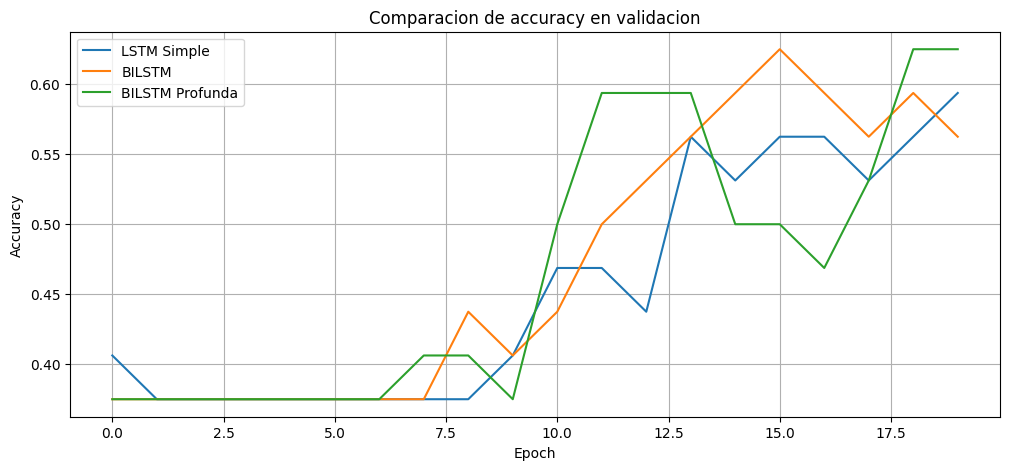

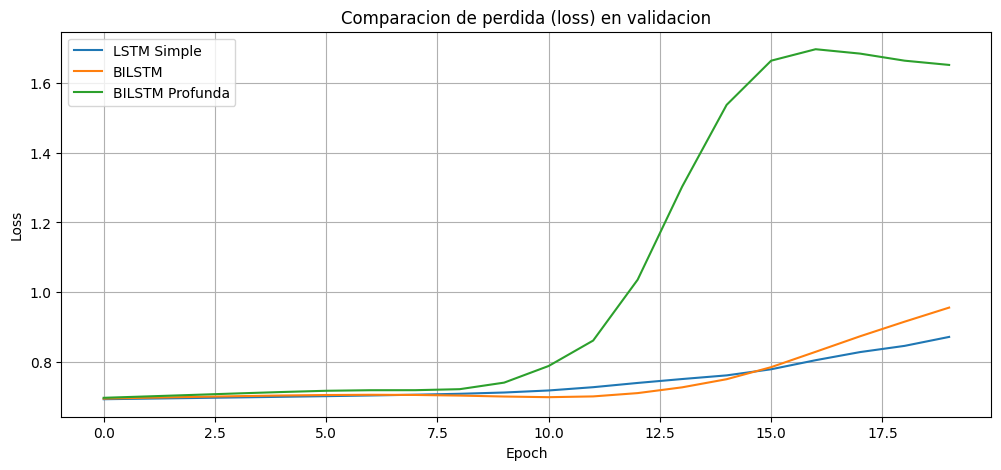

In [8]:
# Gaficamos accuracy y loss

plt.figure(figsize=(12,5))
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM Simple")
plt.plot(hist_bilstm.history["val_accuracy"], label="BILSTM")
plt.plot(hist_bilstm_prof.history["val_accuracy"], label="BILSTM Profunda")
plt.title("Comparacion de accuracy en validacion")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(hist_lstm.history["val_loss"], label="LSTM Simple")
plt.plot(hist_bilstm.history["val_loss"], label="BILSTM")
plt.plot(hist_bilstm_prof.history["val_loss"], label="BILSTM Profunda")
plt.title("Comparacion de perdida (loss) en validacion")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Evaluacion en test

resultado_lstm = modelo_lstm_simple.evaluate(
    X_test_pad,
    np.array(y_test),
    verbose=0
)

resultado_bilstm = modelo_bilstm.evaluate(
    X_test_pad,
    np.array(y_test),
    verbose=0
)

resultado_bilstm_prof = modelo_bilstm_profunda.evaluate(
    X_test_pad,
    np.array(y_test),
    verbose=0
)

print("Resultados en test:")
print(f"LSTM simple            Loss: {resultado_lstm[0]:.4f} | Accuracy: {resultado_lstm[1]:.4f}")
print(f"BILSTM                 Loss: {resultado_bilstm[0]:.4f} | Accuracy: {resultado_bilstm[1]:.4f}")
print(f"BILSTM profunda        Loss: {resultado_bilstm_prof[0]:.4f} | Accuracy: {resultado_bilstm_prof[1]:.4f}")

Resultados en test:
LSTM simple            Loss: 0.9458 | Accuracy: 0.5250
BILSTM                 Loss: 1.2312 | Accuracy: 0.5000
BILSTM profunda        Loss: 1.8565 | Accuracy: 0.5000


In [10]:
# Frases nuevas para probar ambigüedad

frases_nuevas = [
    "el banco estaba frente al parque",
    "el banco aprobo el credito del cliente",
    "la cura fue efectiva para el paciente",
    "el cura prinuncio un discurso en la iglesia"
]

seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)

pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

pred_lstm = modelo_lstm_simple.predict(pad_nuevas, verbose=0)
pred_bilstm = modelo_bilstm.predict(pad_nuevas, verbose=0)
pred_bilstm_prof = modelo_bilstm_profunda.predict(pad_nuevas, verbose=0)

print("Predicciones para frases nuevas:\n")
for i, frase in enumerate(frases_nuevas):
  print(f"Frase: {frase}")
  print(f" LSTM simple                 :{pred_lstm[i][0]:.4f}")
  print(f" BILSTM                      :{pred_bilstm[i][0]:.4f}")
  print(f" BILSTM profunda             :{pred_bilstm_prof[i][0]:.4f}")
  print("-"*90)

Predicciones para frases nuevas:

Frase: el banco estaba frente al parque
 LSTM simple                 :0.1230
 BILSTM                      :0.0061
 BILSTM profunda             :0.0010
------------------------------------------------------------------------------------------
Frase: el banco aprobo el credito del cliente
 LSTM simple                 :0.7507
 BILSTM                      :0.8926
 BILSTM profunda             :0.9820
------------------------------------------------------------------------------------------
Frase: la cura fue efectiva para el paciente
 LSTM simple                 :0.0505
 BILSTM                      :0.0086
 BILSTM profunda             :0.0013
------------------------------------------------------------------------------------------
Frase: el cura prinuncio un discurso en la iglesia
 LSTM simple                 :0.8334
 BILSTM                      :0.9665
 BILSTM profunda             :0.9972
-------------------------------------------------------------------

In [11]:
# Colocar el corpus para la generacion de texto
corpus = [
    # IA
    "la inteligencia artificial aprende patrones",
    "la inteligencia artificial procesa secuencias",
    "la inteligencia artificial necesita datos",
    "la inteligencia artificial transforma industrias",
    "la inteligencia artificial analiza imagenes",
    "la inteligencia artificial mejora procesos",
    "la inteligencia artificial detecta anomalias",
    "la inteligencia artificial puede clasificar texto",
    "la inteligencia artificial ayuda en medicina",
    "la inteligencia artificial requiere evaluacion",

    # redes neuronales
    "las redes neuronales aprenden representaciones",
    "las redes neuronales ajustan pesos",
    "las redes neuronales detectan regularidades",
    "las redes neuronales modelan relaciones complejas",
    "las redes neuronales requieren entrenamiento",
    "las redes neuronales pueden sobreajustar",
    "las redes neuronales usan funciones de activacion",
    "las redes neuronales generan salidas probabilisticas",
    "las redes neuronales dependen de la arquitectura",
    "las redes neuronales capturan patrones ocultos",

    # LSTM
    "las lstm recuerdan informacion importante",
    "las lstm usan compuertas para controlar memoria",
    "las lstm reducen el gradiente desvaneciente",
    "las lstm manejan secuencias largas",
    "las lstm separan estado oculto y celda",
    "las lstm procesan lenguaje natural",
    "las lstm mejoran la memoria temporal",
    "las lstm filtran informacion irrelevante",
    "las lstm conservan contexto a largo plazo",
    "las lstm pueden generar texto",

    # BiLSTM
    "las bilstm leen en dos direcciones",
    "las bilstm usan contexto pasado y futuro",
    "las bilstm mejoran la desambiguacion",
    "las bilstm enriquecen la representacion",
    "las bilstm ayudan en clasificacion de secuencias",
    "las bilstm capturan contexto global",
    "las bilstm se usan en nlp",
    "las bilstm son utiles para etiquetado",
    "las bilstm combinan dos recorridos",
    "las bilstm interpretan mejor frases ambiguas",

    # softmax y salida
    "la salida softmax produce probabilidades",
    "la salida softmax distribuye masa entre tokens",
    "la softmax convierte logits en probabilidades",
    "la softmax normaliza la salida del modelo",
    "la softmax se usa en modelos generativos",
    "la probabilidad mayor no siempre es la elegida",
    "la temperatura controla la diversidad",
    "la temperatura modifica el muestreo",
    "la distribucion softmax guia la generacion",
    "la red estima el siguiente token probable",

    # generación
    "el siguiente token depende de la historia",
    "la generacion autoregresiva repite el proceso",
    "el modelo recibe un prompt inicial",
    "la red predice una palabra nueva",
    "el token generado vuelve al contexto",
    "la generacion continua paso a paso",
    "la secuencia crece palabra por palabra",
    "el muestreo selecciona una continuacion",
    "la generacion depende de probabilidades",
    "la red construye texto iterativamente",

    # regularización
    "el dropout recurrente protege la memoria",
    "el dropout recurrente mantiene la misma mascara",
    "el dropout tradicional rompe la secuencia",
    "la regularizacion evita overfitting",
    "el modelo profundo puede memorizar demasiado",
    "la validacion mide generalizacion",
    "la perdida de validacion puede crecer",
    "el sobreajuste daña el rendimiento futuro",
    "las capas profundas necesitan control",
    "la regularizacion mejora robustez",

    # límite secuencial
    "la generacion secuencial limita la paralelizacion",
    "el procesamiento paso a paso reduce eficiencia",
    "las gpus prefieren operaciones paralelas",
    "la secuencia estricta crea un cuello de botella",
    "los contextos grandes aumentan el costo",
    "el hardware no se aprovecha completamente",
    "la memoria secuencial tiene limites",
    "el tiempo de inferencia crece con la longitud",
    "la paralelizacion parcial sigue siendo dificil",
    "ese limite abrio paso a transformers"
]

print("Total de frases del corpus:", len(corpus))
print("\nPrimeras 10 frases:")
for frase in corpus [:10]:
  print("-", frase)

Total de frases del corpus: 80

Primeras 10 frases:
- la inteligencia artificial aprende patrones
- la inteligencia artificial procesa secuencias
- la inteligencia artificial necesita datos
- la inteligencia artificial transforma industrias
- la inteligencia artificial analiza imagenes
- la inteligencia artificial mejora procesos
- la inteligencia artificial detecta anomalias
- la inteligencia artificial puede clasificar texto
- la inteligencia artificial ayuda en medicina
- la inteligencia artificial requiere evaluacion


In [12]:
tokenizer_gen = Tokenizer()

# Aprendemos el vocabulario del corpus
tokenizer_gen.fit_on_texts(corpus)

# Total del vocabulario del corpus
total_words= len(tokenizer_gen.word_index)+1

# Mostramos vocabulario aprendido
print("Tamaño del vocabulario generativo:", total_words)
print("\nPrimeras palabras del vocabulario:")
for i, (palabra, indice) in enumerate (tokenizer_gen.word_index.items()):
  if i > 15:
    break
  print(f"{palabra}: {indice}")

Tamaño del vocabulario generativo: 231

Primeras palabras del vocabulario:
la: 1
las: 2
el: 3
inteligencia: 4
artificial: 5
redes: 6
neuronales: 7
lstm: 8
bilstm: 9
de: 10
en: 11
softmax: 12
generacion: 13
paso: 14
usan: 15
memoria: 16


In [13]:
# Crear datos para prediccion del siguiente token

input_sequences = []

for frase in corpus:
  # Convertimos la frase a una lista de indices
  token_list = tokenizer_gen.texts_to_sequences([frase])[0]
  # Convertimos una frase en multiples ejemplos
  # Si la frase [1,2,3,4], generamos:
  #[1,2] para predecir 3
  #[1,2,3] para predecir 4

  # Contruiremos secuencias crecientes
  for i in range(1, len(token_list)):
    # Tomamos desde el inicio hasta la posicion iesima
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

print(" Numero total de secuencias generadas:", len(input_sequences))
print("\nPrimeras 10 secuencias generadas:")
for secuencia in input_sequences[:10]:
  print(secuencia)

 Numero total de secuencias generadas: 383

Primeras 10 secuencias generadas:
[1, 4]
[1, 4, 5]
[1, 4, 5, 54]
[1, 4, 5, 54, 31]
[1, 4]
[1, 4, 5]
[1, 4, 5, 55]
[1, 4, 5, 55, 19]
[1, 4]
[1, 4, 5]


In [14]:
# Padding y separamos en X & y
max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding="pre")
)

# X seran todas las columnas menos la ultima
# Historial
X_gen= input_sequences[:, :-1]

#y sera la ultima columna
# La palabra que queremos predecir.
y_gen= input_sequences[:,-1]

# Convertimos y codificamos a one hot
# Esto es necesario por que la salida del modelo sera softmax
# se hara sobre todo el vocabulario
y_gen = tf.keras.utils.to_categorical(y_gen, num_classes=total_words)

print("Dimensiones de X_gen:", X_gen.shape)
print("Dimensiones de y_gen:", y_gen.shape)
print("Longitud maxima:", max_sequence_len)

Dimensiones de X_gen: (383, 7)
Dimensiones de y_gen: (383, 231)
Longitud maxima: 8


In [15]:
# BILSTM APILADA + Recurrent Droput para generativa

modelo_gen = Sequential()

modelo_gen.add(Input(shape=(max_sequence_len - 1,)))

modelo_gen.add(Embedding(input_dim=total_words, output_dim=64))

# Usamos return_sequences = True para que la capa entregue un output por cada palabra
# Si no se hace esto la LSTM devolvería un resumen final (vector) esto solo lo haremos si apilamos una LSTM sobre otra
modelo_gen.add(Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.2)))

#La ultima LSTM ya no necesita return_sequences por que resume todo para la capa Dense final.
# recurrent_dropout apaga conexiones de memoria aleatorias para evitar que la red memorice el dataset (Overfitting)
modelo_gen.add(Bidirectional(LSTM(64, recurrent_dropout=0.2)))

modelo_gen.add(Dense(total_words, activation="softmax"))

modelo_gen.compile(
    optimizer=Adam(learning_rate=0.001),
    loss ="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_gen.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 7, 64)          │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 7, 128)         │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 231)            │        29,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,447 (818.15 KB)

 Trainable params: 209,447 (818.15 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Entrenar el modelo generativo.
hist_gen = modelo_gen.fit(
    X_gen,
    y_gen,
    epochs=100,
    batch_size=8,
    verbose=0
)

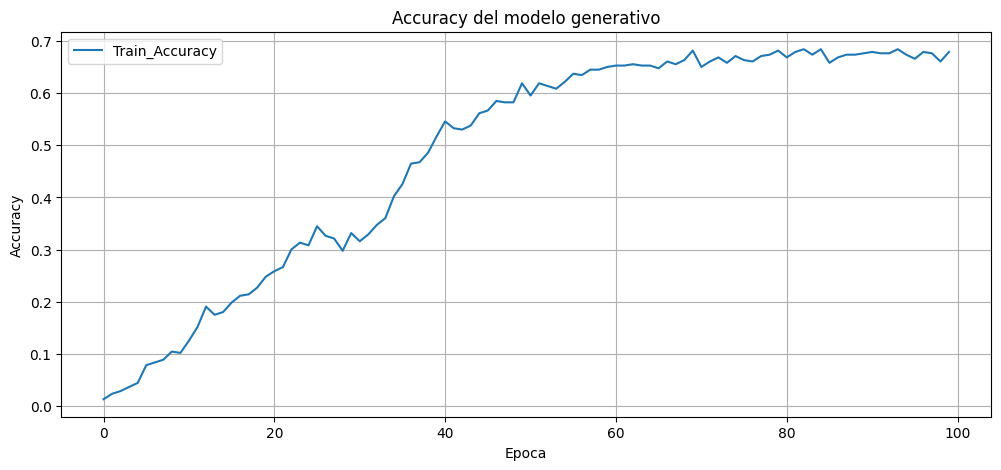

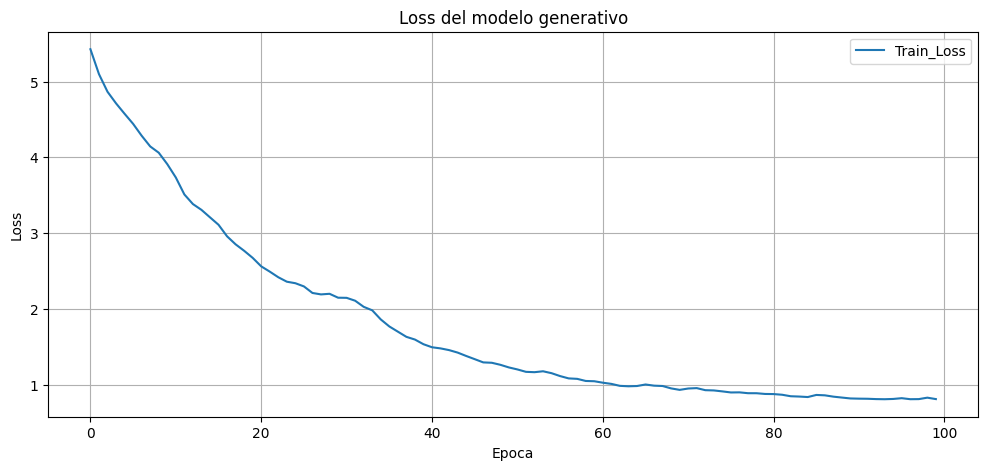

In [17]:
# Graficar accuracy y loss del modelo generativo

# Grafica de accuracy
plt.figure(figsize=(12,5))
plt.plot(hist_gen.history["accuracy"], label="Train_Accuracy")
plt.title("Accuracy del modelo generativo")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Grafica de loss de entrenamiento
plt.figure(figsize=(12,5))
plt.plot(hist_gen.history["loss"], label="Train_Loss")
plt.title("Loss del modelo generativo")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Muestreo con temperatura

# Esta funcion toma la distribucion softmax del modelo
# y decide como muestrear el siguiente token.

# Temperatura baja equivale a un modelo mas conservador
# Temperatura alta equivale a un modelo más diverso / más aleatorio

def sample_with_temperature(probabilidades, temperatura=1.0):
  # Covertimos a numpy float64 para una mayor estabilidad númerica
  probabilidades = np.asarray(probabilidades).astype("float64")

  # Aplicamos logaritmo y ajustamos por temperatura.
  # Esto modifica que tan "picuda" o "plana" queda la distribucion
  probabilidades = np.log(probabilidades + 1e-8) / temperatura

  # Regresamos a escala positiva
  exp_probabilidades = np.exp(probabilidades)

  # Re-normalizamos para que vuelva a sumar 1
  probabilidades = exp_probabilidades / np.sum(exp_probabilidades)

  # muestreamos un indice según esa distribucion dada
  return np.random.choice(len(probabilidades), p=probabilidades)


In [20]:
# Generacion autoregresiva

# Esta función implementa exactamente el bucle autoregresivo:

# 1) Damos un prompt
# 2) El modelo predice una distribución del siguiente token
# 3) Muestreamos una palabra
# 4) La agregamos al contexto
# 5) Rpetimos el proceso

def generar_texto(modelo, tokenizer, seed_text, max_sequence_len,
                  n_palabras=6, temperatura=1.0):

  # Modelo: Red entrenada
  # Tokenizer: Tokenizer del corpus
  # Seed_text: Prompt inicial
  # max_sequence_len: longitud máxima usada por el modelo
  # n_palabras: Cuantas palabras nuevas queremos generar
  # temperatura: controla la diversidad

  # Repetimos el bucle de generación
  for _ in range(n_palabras):

    # Convertimos el texto actual a secuencia de enteros
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    # Aplicamos el mismo padding "pre" que usamos en el entrenamiento
    # Aplicamos el padding para que la entrada tenga el tamaño esperado
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1,
                               padding="pre")
    # Obtenemos la distribución softmax del siguiente token
    # obtenemos el vector de probabilidades de todo el vocabulario
    predicted_probs = modelo(token_list, training=False).numpy()[0]

    # Muestreamos un índice usando la temperatura elegida
    # Elegimos el índice de la siguiente palabra usando la temperatura
    predicted_index = sample_with_temperature(predicted_probs, temperatura=temperatura)

    # Buscamos  que palabra corresponde a ese indice
    # Decodificamos el índice de vuelta a la palabra en texto
    output_word = ""
    for palabra, indice in tokenizer.word_index.items():
      if indice == predicted_index:
        output_word = palabra
        break

    # Si no encontramos palabra, detenemos la generación
    if output_word == "":
      break

    # Agregamos la palabra al prompt inicial
    seed_text += " " + output_word
  return seed_text

In [21]:
# Probamos la generación con distintos prompts

prompts =[
    "la inteligencia",
    "las lstm",
    "la salida",
    "el siguiente"]

for prompt in prompts:
  print("Prompt:", prompt)

  print("Temperatura 0.7:", generar_texto(
      modelo_gen,
      tokenizer_gen,
      prompt,
      max_sequence_len,
      n_palabras=6,
      temperatura=0.7
  ))

  print("Temperatura 1.0:", generar_texto(
      modelo_gen,
      tokenizer_gen,
      prompt,
      max_sequence_len,
      n_palabras=6,
      temperatura=1.0
  ))

  print("-"*90)

Prompt: la inteligencia
Temperatura 0.7: la inteligencia artificial mejora procesos cuello de celda
Temperatura 1.0: la inteligencia artificial necesita datos datos generativos celda
------------------------------------------------------------------------------------------
Prompt: las lstm
Temperatura 0.7: las lstm reducen el gradiente desvaneciente desvaneciente celda
Temperatura 1.0: las lstm pueden generar texto temporal mascara mascara
------------------------------------------------------------------------------------------
Prompt: la salida
Temperatura 0.7: la salida softmax distribuye masa entre tokens tokens
Temperatura 1.0: la salida softmax produce probabilidades probabilidades proceso elegida
------------------------------------------------------------------------------------------
Prompt: el siguiente
Temperatura 0.7: el siguiente token depende de la historia longitud
Temperatura 1.0: el siguiente token depende de la historia longitud
---------------------------------------